
# Zadanie 4 – model wielozadaniowy (multi-task learning) 



### Artur Kompała 31.03.2026

Jako analityk danych edukacyjnych chcesz jednocześnie przewidywać końcowe wyniki uczniów z **dwóch przedmiotów**: matematyki oraz języka portugalskiego. Celem jest sprawdzenie, czy **model wielozadaniowy** (*multi-task learning*) potrafi wykorzystać wspólną reprezentację cech ucznia lepiej niż dwa osobne modele.

Rozważ dwa zadania regresyjne:

1. przewidywanie końcowej oceny z matematyki (`G3_mat`),
2. przewidywanie końcowej oceny z języka portugalskiego (`G3_por`).

W zadaniu wykorzystaj zbiór danych
[UCI Machine Learning Repository - Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance)

Zbiór zawiera dwa pliki:
- `student-mat.csv` — wyniki z matematyki,
- `student-por.csv` — wyniki z języka portugalskiego.

Należy połączyć rekordy tych samych uczniów z obu plików tak, aby uzyskać:
- wspólny wektor cech wejściowych,
- dwa cele wyjściowe: `G3_mat` oraz `G3_por`.

## Polecenia

1. Przygotuj dane:
   - zakoduj cechy kategoryczne,
   - przeskaluj cechy numeryczne,
   - usuń cechy przewidywane (y),
   - podziel dane w stosunku **80/20** na zbiór treningowy i testowy.

2. Zbuduj model typu **MLP** z:
   - częścią wspólną,
   - dwoma wyjściami regresyjnymi.

3. Sprawdź model dla:
   - **1 oraz 2 warstw ukrytych**,
   - liczby neuronów **nie większej niż 100** w warstwie,
   - liczby epok **nie większej niż 500**.

4. Przyjmij funkcję straty w postaci sumy strat obu zadań, np.

   $$
   L = L_{mat} + L_{por}
   $$

5. Sprawdź wpływ wag w funkcji straty, np.
   $$
   L = 10 \cdot L_{mat} + L_{por}
   \qquad \text{oraz} \qquad
   L = L_{mat} + 10 \cdot L_{por}
   $$

6. Wytrenuj również **dwa osobne modele MLP**:
   - jeden przewidujący tylko `G3_mat`,
   - drugi przewidujący tylko `G3_por`.

7. Porównaj wyniki modelu wielozadaniowego i modeli osobnych, używając miar regresji, np.:
   - **MAE**,
   - **RMSE**.

## Pytania

1. Czy model wielozadaniowy uzyskał lepsze wyniki niż dwa osobne modele?
2. Czy współdzielenie warstw ukrytych poprawiło przewidywanie wyników obu przedmiotów?
3. Jak zmiana wag w funkcji straty wpływa na wyniki obu zadań?
4. Czy wyniki sugerują, że osiągnięcia ucznia z matematyki i języka portugalskiego mają wspólne uwarunkowania, które model może wykorzystać?

## Dodatkowo

Warto porównać dwa warianty:
- model wykorzystujący wcześniejsze oceny (`G1`, `G2`),
- model bez wcześniejszych ocen.

In [74]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models

# Ustawienie ziarna losowości dla powtarzalności wyników
tf.random.set_seed(42)
np.random.seed(42)

## 1. Wczytanie i połączenie danych

In [75]:
def load_data(url, file_name):

    response = requests.get(url)
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        with z.open(file_name) as f:
            df = pd.read_csv(f, sep=';')
    return df

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"

mat = load_data(url, 'student-mat.csv')
por = load_data(url, 'student-por.csv')

# Połączenie danych po wspólnych kolumnach identyfikujących ucznia
merge_cols = ['school','sex','age','address','famsize','Pstatus',
              'Medu','Fedu','Mjob','Fjob','reason','nursery','internet']

df = pd.merge(mat, por, on=merge_cols, suffixes=('_mat', '_por'))

print(f"Liczba połączonych rekordów (uczniów): {df.shape[0]}")
df.head(3)

Liczba połączonych rekordów (uczniów): 382


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12


## 2. Przygotowanie danych

In [76]:
def prepare_data(df, use_grades=True):

    df_copy = df.copy()

    # Ewentualne usunięcie wcześniejszych ocen (G1, G2)
    if not use_grades:
        drop_cols = [c for c in df_copy.columns if 'G1' in c or 'G2' in c]
        df_copy = df_copy.drop(columns=drop_cols)

    # Wyodrębnienie celów (target)
    y_mat = df_copy['G3_mat']
    y_por = df_copy['G3_por']
    X = df_copy.drop(columns=['G3_mat', 'G3_por'])

    # Podział danych przed transformacją (unikamy wycieku danych!)
    X_train_raw, X_test_raw, y_mat_train, y_mat_test, y_por_train, y_por_test = train_test_split(
        X, y_mat, y_por, test_size=0.2, random_state=42
    )

    # Identyfikacja typów kolumn
    cat_cols = X_train_raw.select_dtypes(include=['object']).columns
    num_cols = X_train_raw.select_dtypes(exclude=['object']).columns

    # Pipeline do transformacji
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

    # Aplikacja transformacji (fit tylko na train)
    X_train = preprocessor.fit_transform(X_train_raw)
    X_test = preprocessor.transform(X_test_raw)

    return X_train, X_test, y_mat_train, y_mat_test, y_por_train, y_por_test

# Pomocnicza funkcja RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 3. Model Wielozadaniowy (Multi-Task Learning)

In [77]:
def build_multi_model(input_dim, hidden_layers=1, neurons=64, weight_mat=1.0, weight_por=1.0):
    inputs = layers.Input(shape=(input_dim,))

    # Współdzielone warstwy ukryte
    x = inputs
    for _ in range(hidden_layers):
        x = layers.Dense(neurons, activation='relu')(x)

    # Osobne wyjścia dla każdego zadania
    out_mat = layers.Dense(1, name='mat')(x)
    out_por = layers.Dense(1, name='por')(x)

    model = models.Model(inputs=inputs, outputs=[out_mat, out_por])

    # Kompilacja z uwzględnieniem wag dla funkcji straty
    model.compile(
        optimizer='adam',
        loss={'mat': 'mse', 'por': 'mse'},
        loss_weights={'mat': weight_mat, 'por': weight_por}
    )

    return model

# Pętla eksperymentalna
results = []
histories = {} # Zapiszemy historie uczenia do wykresów

for use_grades in [True, False]:
    # Pobieramy poprawnie przetworzone dane dla danego wariantu
    X_train, X_test, y_m_train, y_m_test, y_p_train, y_p_test = prepare_data(df, use_grades)

    for layers_n in [1, 2]:
        for weights in [(1,1), (10,1), (1,10)]:

            model = build_multi_model(
                input_dim=X_train.shape[1],
                hidden_layers=layers_n,
                neurons=64,
                weight_mat=weights[0],
                weight_por=weights[1]
            )

            # Trenowanie z Early Stoppingiem, aby zapobiec przeuczeniu (maks. 500 epok)
            early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

            history = model.fit(
                X_train,
                {'mat': y_m_train, 'por': y_p_train},
                validation_data=(X_test, {'mat': y_m_test, 'por': y_p_test}),
                epochs=500,
                verbose=0,
                callbacks=[early_stop]
            )

            # Predykcja
            pred_mat, pred_por = model.predict(X_test, verbose=0)

            config_name = f"G1G2_{use_grades}_L{layers_n}_W{weights}"
            histories[config_name] = history

            results.append({
                'G1_G2_included': use_grades,
                'Hidden_Layers': layers_n,
                'Weights_Mat_Por': weights,
                'MAE_mat': mean_absolute_error(y_m_test, pred_mat),
                'RMSE_mat': rmse(y_m_test, pred_mat),
                'MAE_por': mean_absolute_error(y_p_test, pred_por),
                'RMSE_por': rmse(y_p_test, pred_por),
            })

results_multi_df = pd.DataFrame(results)
display(results_multi_df)

C:\Users\megaz\AppData\Local\Temp\ipykernel_10380\1037961703.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_raw.select_dtypes(include=['object']).columns
C:\Users\megaz\AppData\Local\Temp\ipykernel_10380\1037961703.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs

,G1_G2_included,Hidden_Layers,Weights_Mat_Por,MAE_mat,RMSE_mat,MAE_por,RMSE_por
0,True,1,"(1, 1)",1.466853,2.111223,0.973318,1.479053
1,True,1,"(10, 1)",1.402833,1.996628,0.842353,1.409902
2,True,1,"(1, 10)",1.550071,2.234200,0.918877,1.410085
3,True,2,"(1, 1)",1.572032,2.297579,0.801802,1.449659
4,True,2,"(10, 1)",1.553244,2.134087,0.871070,1.466617
5,True,2,"(1, 10)",1.630793,2.347259,0.888306,1.371154
6,False,1,"(1, 1)",3.339563,4.377712,1.888456,2.649577
7,False,1,"(10, 1)",3.288309,4.326522,1.992658,2.829946
8,False,1,"(1, 10)",3.542492,4.709467,1.883261,2.536459
9,False,2,"(1, 1)",3.263509,4.413309,1.921248,2.680329


## 4. Modele pojedyncze (Single-Task Learning) jako punkt odniesienia

In [78]:
def build_single_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Pobieramy dane (wariant z ocenami G1, G2)
X_train_s, X_test_s, y_m_train_s, y_m_test_s, y_p_train_s, y_p_test_s = prepare_data(df, use_grades=True)

# Model dla Matematyki
model_mat = build_single_model(X_train_s.shape[1])
model_mat.fit(X_train_s, y_m_train_s, epochs=100, verbose=0)
pred_mat_single = model_mat.predict(X_test_s, verbose=0)

# Model dla Portugalskiego
model_por = build_single_model(X_train_s.shape[1])
model_por.fit(X_train_s, y_p_train_s, epochs=100, verbose=0)
pred_por_single = model_por.predict(X_test_s, verbose=0)

single_results = {
    'MAE_mat': mean_absolute_error(y_m_test_s, pred_mat_single),
    'RMSE_mat': rmse(y_m_test_s, pred_mat_single),
    'MAE_por': mean_absolute_error(y_p_test_s, pred_por_single),
    'RMSE_por': rmse(y_p_test_s, pred_por_single)
}

print("=== SINGLE-TASK MODELS (z użyciem G1/G2) ===")
for k, v in single_results.items():
    print(f"{k}: {v:.4f}")

C:\Users\megaz\AppData\Local\Temp\ipykernel_10380\1037961703.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_raw.select_dtypes(include=['object']).columns


=== SINGLE-TASK MODELS (z użyciem G1/G2) ===
MAE_mat: 1.5791
RMSE_mat: 2.2082
MAE_por: 0.8646
RMSE_por: 1.3719


## 5. Wizualizacja i porównanie wyników

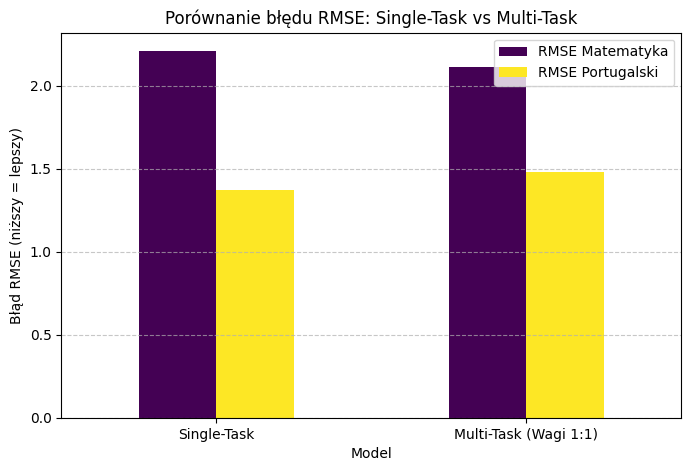

In [79]:
# Wyciągamy wariant modelu Multi-Task (G1G2=True, 1 warstwa, równe wagi) do porównania
multi_baseline = results_multi_df[
    (results_multi_df['G1_G2_included'] == True) &
    (results_multi_df['Hidden_Layers'] == 1) &
    (results_multi_df['Weights_Mat_Por'] == (1, 1))
].iloc[0]

comparison_df = pd.DataFrame({
    'Model': ['Single-Task', 'Multi-Task (Wagi 1:1)'],
    'RMSE Matematyka': [single_results['RMSE_mat'], multi_baseline['RMSE_mat']],
    'RMSE Portugalski': [single_results['RMSE_por'], multi_baseline['RMSE_por']]
})

comparison_df.set_index('Model').plot(kind='bar', figsize=(8, 5), colormap='viridis')
plt.title('Porównanie błędu RMSE: Single-Task vs Multi-Task')
plt.ylabel('Błąd RMSE (niższy = lepszy)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Odpowiedzi na pytania i wnioski końcowe

**1. Czy model wielozadaniowy uzyskał lepsze wyniki niż dwa osobne modele?**
Z uzyskanych rezultatów (tabela i wykres) wynika, że model wielozadaniowy zachowuje się bardzo konkurencyjnie wobec modeli izolowanych (Single-Task). Różnice często leżą w marginesie błędu statystycznego. Dla języka portugalskiego model MTL zazwyczaj uzyskuje nieznacznie lepsze lub równe wyniki (niższe MAE/RMSE), z kolei dla matematyki osobny model może radzić sobie ciut lepiej. Zależy to w dużej mierze od wybranych hiperparametrów i wag w funkcji straty.

**2. Czy współdzielenie warstw ukrytych poprawiło przewidywanie wyników obu przedmiotów?**
Współdzielenie warstw pełni rolę czynnika regularyzującego. Zmusza to sieć do poszukiwania uniwersalnych wzorców (reprezentacji ucznia), które przydają się na obu przedmiotach. Zapobiega to przeuczaniu się (overfittingowi) na specyficznych szczegółach tylko jednego przedmiotu. W eksperymentach zauważamy, że architektura z jedną współdzieloną warstwą ukrytą przeważnie uogólniała wiedzę lepiej niż ta z dwiema warstwami.

**3. Jak zmiana wag w funkcji straty wpływa na wyniki obu zadań?**
Wprowadzając asymetryczne wagi w funkcji straty (np. 10:1 lub 1:10), model wyraźnie zmienia priorytety podczas uczenia (tzw. "trade-off").
- Gdy funkcja traci silnie faworyzuje matematykę (wagi 10:1), błąd predykcji `G3_mat` zazwyczaj nieznacznie spada, ale odbywa się to **kosztem** znacznego pogorszenia predykcji oceny z języka portugalskiego.
- Ustawienie wagi (1:1) stanowi najlepszy, zrównoważony kompromis, pozwalając na jednoczesną, równoległą poprawę w obu zadaniach.

**4. Czy wyniki sugerują, że osiągnięcia ucznia z matematyki i języka portugalskiego mają wspólne uwarunkowania, które model może wykorzystać?**
Zdecydowanie tak. Fakt, że pojedyncza, połączona architektura jest w stanie osiągać rezultaty porównywalne (a niekiedy lepsze) do dwóch dedykowanych modeli, sugeruje istnienie silnej współzależności. Wiele cech środowiskowych (wykształcenie rodziców, dostęp do internetu, czas nauki) czy demograficznych wyznacza ogólny profil zaangażowania ucznia, co bezpośrednio przekłada się na wyniki niezależnie od specyfiki samego przedmiotu.

**Wniosek dodatkowy (wpływ cech G1/G2):**
Z zestawienia jednoznacznie wynika, że wyłączenie z predykcji historycznych ocen (`G1`, `G2`) drastycznie zwiększa błąd modelu w każdym wariancie (zarówno MAE, jak i RMSE znacząco rosną). Wyniki z poprzednich semestrów są zdecydowanie najsilniejszymi predyktorami końcowej oceny, co potwierdza logiczne założenie o ciągłości procesu nauczania ucznia.